In [4]:
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms 
device = 'cuda' if torch.cuda.is_available() else 'cpu' #imports


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
]) #normaliza a imagem

In [6]:
trn_ds = MNIST('data', transform = img_transform, train = True, download = True)
val_ds = MNIST('data', transform = img_transform, train = False, download = True) #dados de treino e teste

In [7]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False) #define o batch e embaralha os dados

In [8]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True),
            #nn.Linear(64, 12),  nn.ReLU(True),
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(
            #nn.Linear(latent_dim, 12), nn.ReLU(True),
            nn.Linear(latent_dim, 64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True),
            nn.Linear(128, 28 * 28), nn.Tanh())

    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [9]:
def train_batch(input, model, criterion, optimizer):
    model.train() #treino
    optimizer.zero_grad() #zera pra proxima etapa
    output = model(input) #saida
    loss = criterion(output, input)
    loss.backward()
    optimizer.step() #atualiza os pesos
    return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval() #testa
    output = model(input) 
    loss = criterion(output, input)
    return loss #retorna o erro

EPOCH: 1.000  trn_loss: 0.257  val_loss: 0.195  (9.14s - 36.57s remaining)
EPOCH: 2.000  trn_loss: 0.178  val_loss: 0.166  (18.27s - 27.40s remaining)
EPOCH: 3.000  trn_loss: 0.160  val_loss: 0.156  (27.68s - 18.45s remaining)
EPOCH: 4.000  trn_loss: 0.154  val_loss: 0.151  (37.23s - 9.31s remaining)
EPOCH: 5.000  trn_loss: 0.149  val_loss: 0.148  (46.91s - 0.00s remaining)


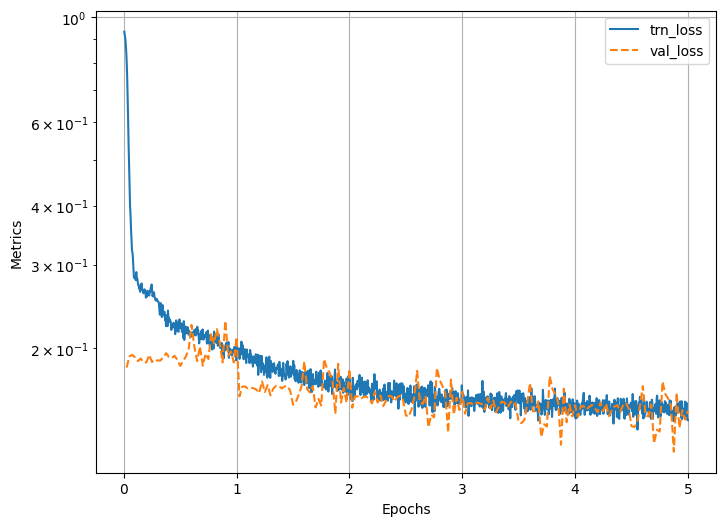

In [10]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs) #epochs

for epoch in range(num_epochs): #todas as epochs
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl): #todos os batchs
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r') #pega o erro do treino e guarda

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl): #testes
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r') #testa e pega o erro
    log.report_avgs(epoch+1)
log.plot(log=True)

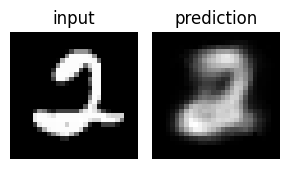

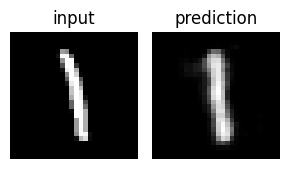

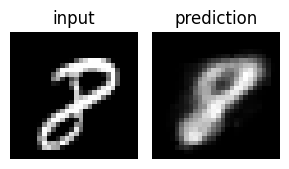

In [13]:
import matplotlib.pyplot as plt
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1,2,figsize=(3,3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show() #mostra o input e oq o modelo previu

EPOCH: 1.000  trn_loss: 0.235  val_loss: 0.134  (8.02s - 32.08s remaining)
EPOCH: 2.000  trn_loss: 0.116  val_loss: 0.100  (18.30s - 27.45s remaining)
EPOCH: 3.000  trn_loss: 0.093  val_loss: 0.085  (29.16s - 19.44s remaining)
EPOCH: 4.000  trn_loss: 0.081  val_loss: 0.076  (39.18s - 9.80s remaining)
EPOCH: 5.000  trn_loss: 0.074  val_loss: 0.069  (46.87s - 0.00s remaining)


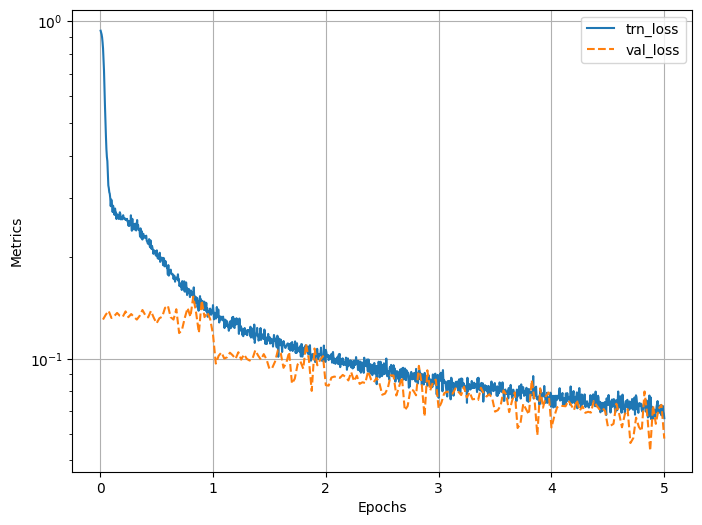

EPOCH: 1.000  trn_loss: 0.266  val_loss: 0.207  (7.48s - 29.90s remaining)
EPOCH: 2.000  trn_loss: 0.196  val_loss: 0.186  (16.04s - 24.07s remaining)
EPOCH: 3.000  trn_loss: 0.183  val_loss: 0.178  (25.16s - 16.78s remaining)
EPOCH: 4.000  trn_loss: 0.176  val_loss: 0.173  (34.10s - 8.53s remaining)
EPOCH: 5.000  trn_loss: 0.172  val_loss: 0.169  (42.64s - 0.00s remaining)


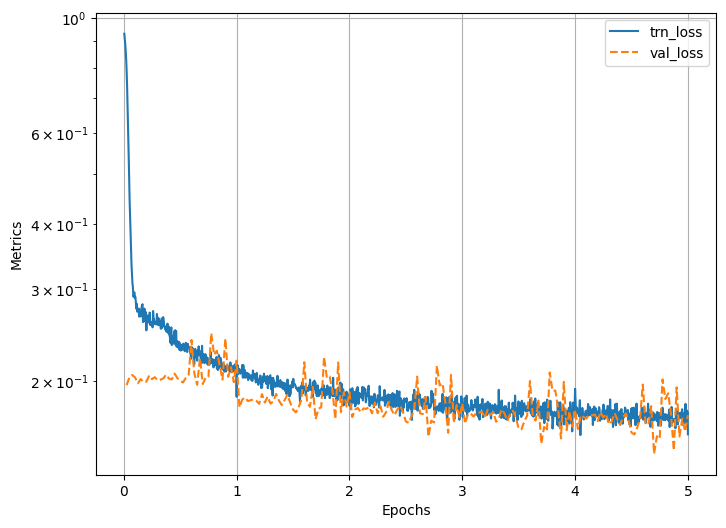

EPOCH: 1.000  trn_loss: 0.249  val_loss: 0.185  (9.28s - 37.13s remaining)
EPOCH: 2.000  trn_loss: 0.173  val_loss: 0.164  (17.03s - 25.55s remaining)
EPOCH: 3.000  trn_loss: 0.160  val_loss: 0.156  (24.61s - 16.41s remaining)
EPOCH: 4.000  trn_loss: 0.154  val_loss: 0.151  (32.71s - 8.18s remaining)
EPOCH: 5.000  trn_loss: 0.150  val_loss: 0.148  (42.46s - 0.00s remaining)


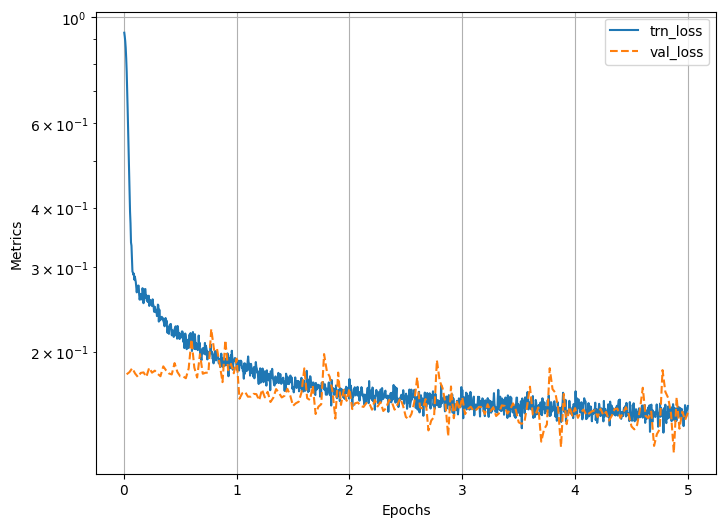

EPOCH: 1.000  trn_loss: 0.244  val_loss: 0.164  (10.74s - 42.96s remaining)
EPOCH: 2.000  trn_loss: 0.148  val_loss: 0.138  (22.68s - 34.02s remaining)
EPOCH: 3.000  trn_loss: 0.133  val_loss: 0.129  (31.56s - 21.04s remaining)
EPOCH: 4.000  trn_loss: 0.126  val_loss: 0.123  (40.98s - 10.25s remaining)
EPOCH: 5.000  trn_loss: 0.121  val_loss: 0.120  (50.06s - 0.00s remaining)


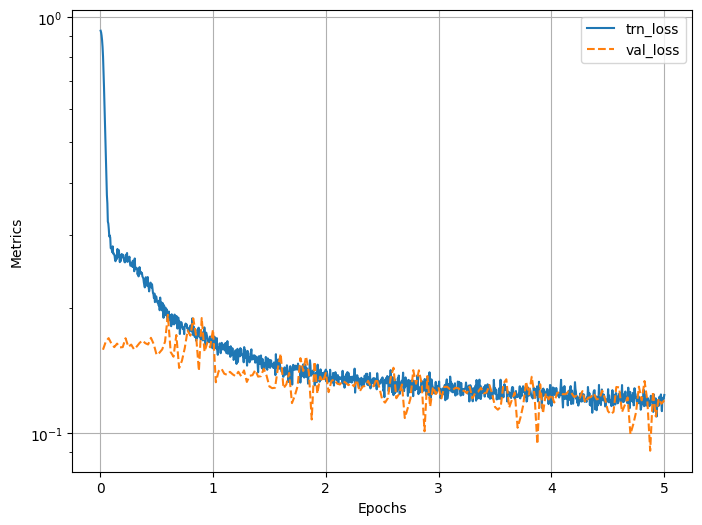

EPOCH: 1.000  trn_loss: 0.249  val_loss: 0.152  (9.90s - 39.59s remaining)
EPOCH: 2.000  trn_loss: 0.131  val_loss: 0.115  (18.96s - 28.45s remaining)
EPOCH: 3.000  trn_loss: 0.107  val_loss: 0.099  (28.33s - 18.89s remaining)
EPOCH: 4.000  trn_loss: 0.097  val_loss: 0.093  (37.47s - 9.37s remaining)
EPOCH: 5.000  trn_loss: 0.092  val_loss: 0.089  (45.60s - 0.00s remaining)


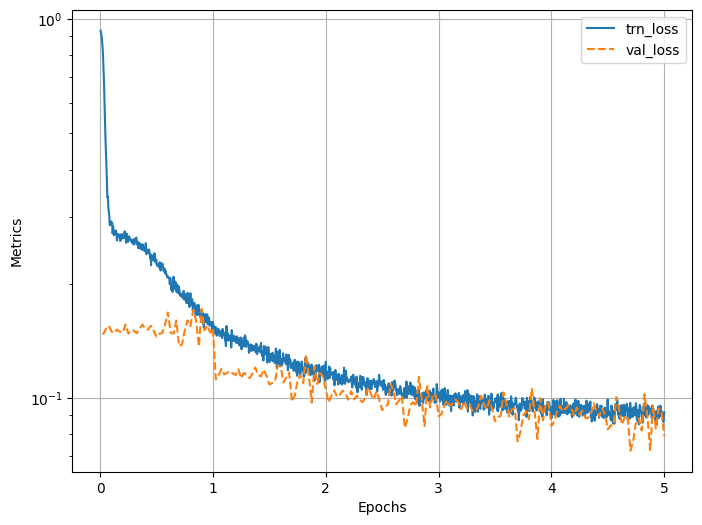

In [14]:
def train_aec(latent_dim):
    model = AutoEncoder(latent_dim).to(device) #cria o modelo
    criterion = nn.MSELoss() #funcao de perda
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5) #otimizador
 
    num_epochs = 5
    log = Report(num_epochs) #epochs e o log

    for epoch in range(num_epochs): 
        N = len(trn_dl)
        for ix, (data, _) in enumerate(trn_dl): #pra todo batch na epoch
            loss = train_batch(data, model, criterion, optimizer)
            log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r') #treina e pega o erro

        N = len(val_dl)
        for ix, (data, _) in enumerate(val_dl): #testa e pega o erro
            loss = validate_batch(data, model, criterion)
            log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
        log.report_avgs(epoch+1)
    log.plot(log=True)
    return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]] #diferentes dimensoes

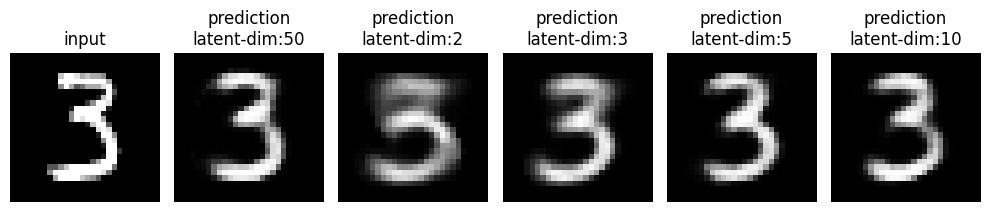

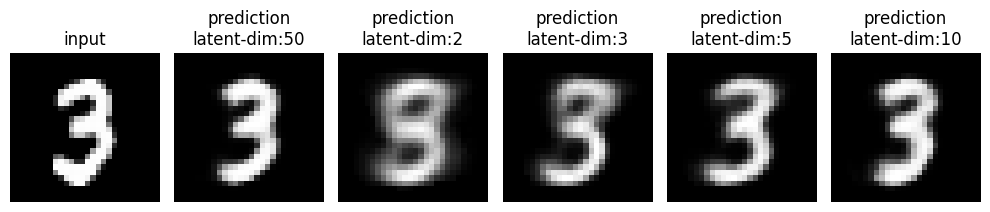

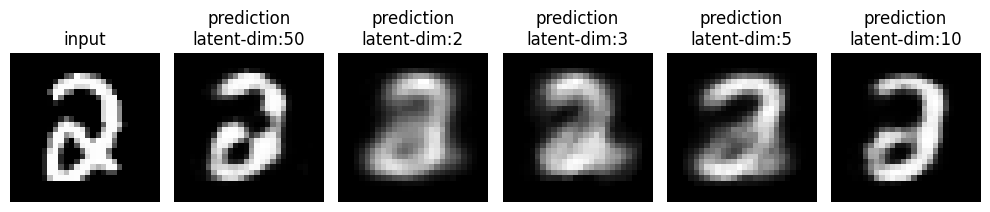

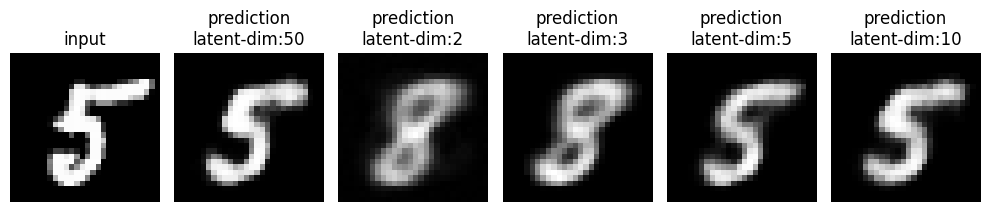

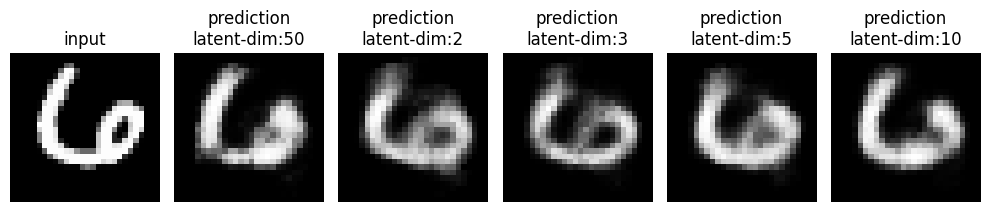

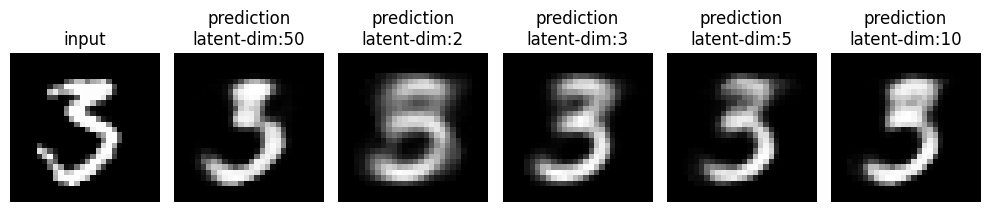

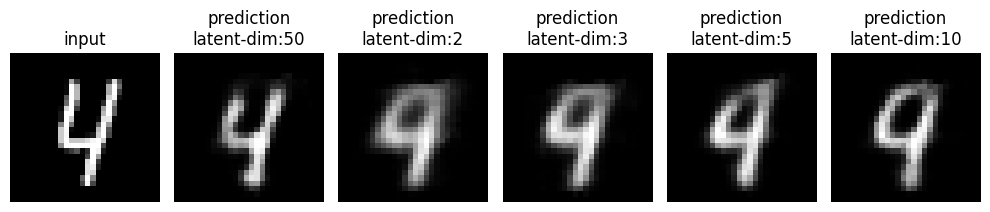

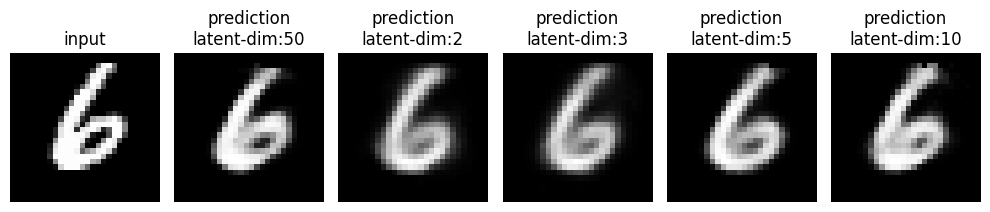

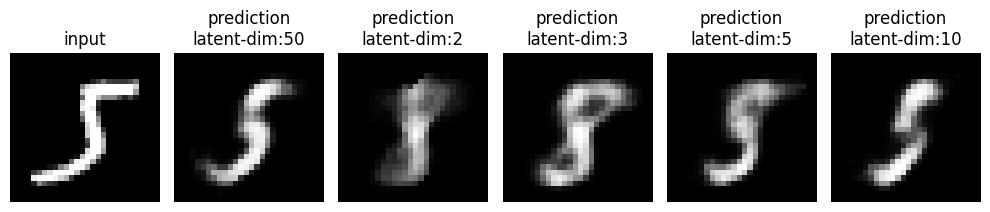

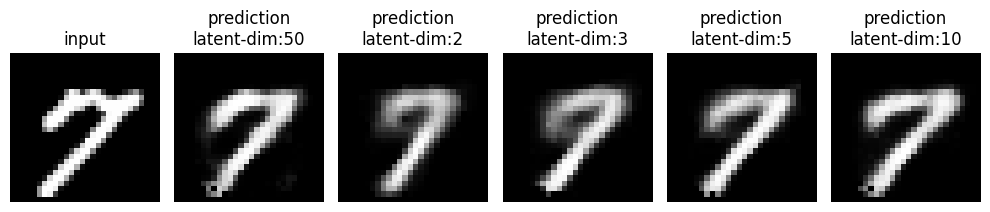

In [15]:
for _ in range(10):
    ix = np.random.randint(len(val_ds)) #pega uma imagme
    im, _ = val_ds[ix] #pega o conjunto de teste
    fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
    ax = iter(ax.flat)
    show(im[0], ax=next(ax), title='input') #pega a imagem original
    for model in aecs: #mostra todos os testes
        _im = model(im[None])[0]
        show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim:{model.latend_dim}')
    plt.tight_layout()
    plt.show()